In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Excel dataset Upload

df=pd.read_excel("/content/sales_data.xlsx")

In [3]:
#Data Cleaning

df.head()

,Order_ID,Order_Date,Customer_Name,Category,Product,Region,Quantity,Sales,Profit
0,ORD001,2025-01-05,Rahul Sharma,Technology,Laptop,West,2,80000.0,12000.0
1,ORD00,2025-02-12,Priya Patil,Furniture,Chair,South,5,25000.0,5000.0
2,ORD003,2025-02-20,Suvarna Ukirde,Office Supplies,Notebook,East,10,5000.0,1500.0
3,ORD004,2025-02-20,Tanuja Ukirde,Technology,Mobile,North,3,45000.0,9000.0
4,ORD005,2025-03-22,Rupali Vitnor,Furniture,Table,West,2,35000.0,6000.0


In [4]:
df.shape

(100, 9)

In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Category', 'Product',
       'Region', 'Quantity', 'Sales', 'Profit'],
      dtype='object')

In [6]:
#Basic Analysis
df.isnull()

,Order_ID,Order_Date,Customer_Name,Category,Product,Region,Quantity,Sales,Profit
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       100 non-null    object        
 1   Order_Date     100 non-null    datetime64[ns]
 2   Customer_Name  100 non-null    object        
 3   Category       100 non-null    object        
 4   Product        100 non-null    object        
 5   Region         100 non-null    object        
 6   Quantity       100 non-null    int64         
 7   Sales          100 non-null    float64       
 8   Profit         100 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 7.2+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Order_Date,Quantity,Sales,Profit
count,100,100.00000,100.000000,100.000000
mean,2014-12-11 07:55:12,4.88000,107500.233455,5184.166667
min,2001-07-03 00:00:00,1.00000,560.000000,100.000000
25%,2007-03-20 06:00:00,2.00000,8658.333333,700.000000
50%,2018-05-05 00:00:00,3.00000,40500.000000,1750.000000
75%,2022-08-29 18:00:00,6.00000,71171.000000,6500.000000
max,2026-10-06 00:00:00,20.00000,980000.000000,34000.000000
std,NaN,4.31413,191789.979371,7162.377299


In [10]:
#KPL Cards

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = df['Sales'].mean()

print("Total_Sales:",total_sales)
print("Total_Profit:",total_profit)
print("Total_Orders:",total_orders)
print("Avg_order_Values:",avg_order_value)



Total_Sales: 10750023.345454546
Total_Profit: 518416.6666666666
Total_Orders: 100
Avg_order_Values: 107500.23345454545


In [11]:
# interactive filters
categories = df['Category'].unique()

print("Available Categories:")
print(categories)

Available Categories:
['Technology' 'Furniture' 'Office Supplies']


In [12]:
regions = df['Region'].unique()

print("Available Regions:")
print(regions)

Available Regions:
['West' 'South' 'East' 'North']


In [13]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.8 MB/s eta 0:00:00


In [14]:
import ipywidgets as widgets
from IPython.display import display

In [15]:
category_filter = widgets.Dropdown(
    options=["All"] + list(df["Category"].unique()),
    description="Category:"

)
region_filter = widgets.Dropdown(
    options=["All"] + list(df["Region"].unique()),
    description="Region:"

)
display(category_filter)
display(region_filter)


Dropdown(description='Category:', options=('All', 'Technology', 'Furniture', 'Office Supplies'), value='All')

Dropdown(description='Region:', options=('All', 'West', 'South', 'East', 'North'), value='All')

In [16]:
def filter_data(category, region):
  filtered_df = df.copy()
  #apply category filter
  if category !="All":
    filtered_df = filtered_df[filtered_df["Category"]==category]
    #apply region filter
    if region_filter !="All":
      filtered_df = filtered_df[filtered_df["Region"]==region]

      return filtered_df

In [17]:
filtered_df = filter_data(
    category_filter.value,
    region_filter.value
)
filtered_df

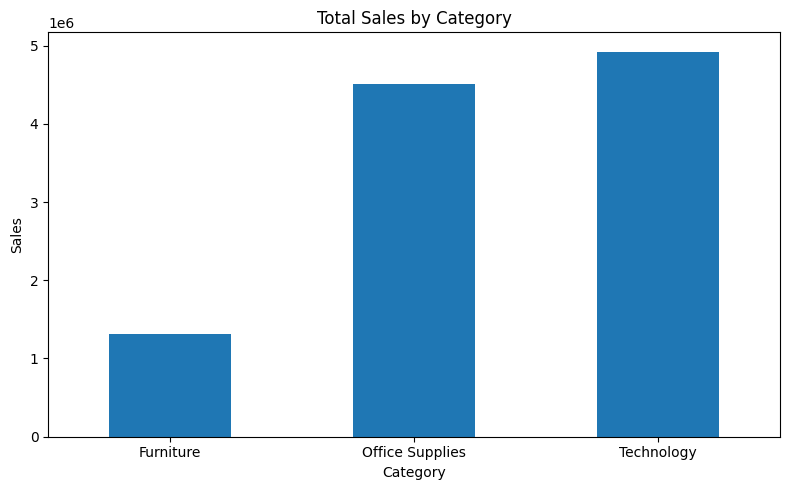

In [18]:
from pandas.core.indexes import category
category_sales = df.groupby("Category")['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
East     2.263336e+06
North    1.988924e+06
South    2.799198e+06
West     3.698565e+06
Name: Sales, dtype: float64


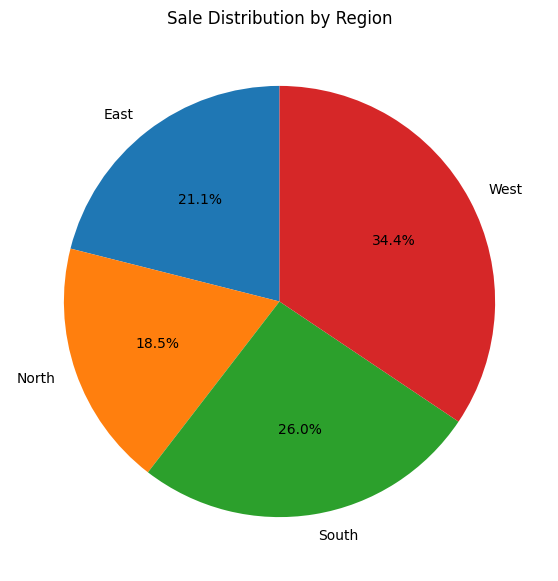

In [19]:
region_sales = df.groupby("Region")['Sales'].sum()
print(region_sales)

region_sales = df.groupby("Region")['Sales'].sum()
plt.figure(figsize=(7,7))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sale Distribution by Region")
plt.show()

Month
April        1.104085e+06
August       1.657000e+06
February     3.210300e+06
January      1.068044e+06
July         4.350000e+05
June         8.510000e+05
March        1.259000e+06
May          1.086365e+05
October      7.311700e+05
September    3.257880e+05
Name: Sales, dtype: float64


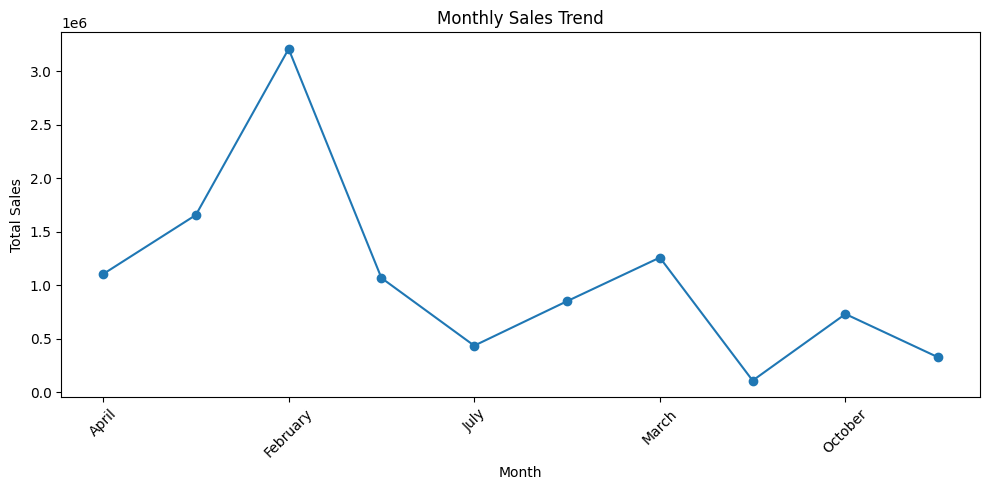

In [20]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"]= df["Order_Date"].dt.strftime("%B")
df[["Order_Date","Month","Sales"]]
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line",marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print(product_sales)


Product
Chair         3.020946e+06
Mobile        2.245324e+06
Laptop        1.959317e+06
Notebook      1.528436e+06
Pen           7.349000e+05
Headphones    7.178000e+05
Table         5.433000e+05
Name: Sales, dtype: float64


In [22]:
top_5_products = product_sales.head(5)
print(top_5_products)

Product
Chair       3.020946e+06
Mobile      2.245324e+06
Laptop      1.959317e+06
Notebook    1.528436e+06
Pen         7.349000e+05
Name: Sales, dtype: float64


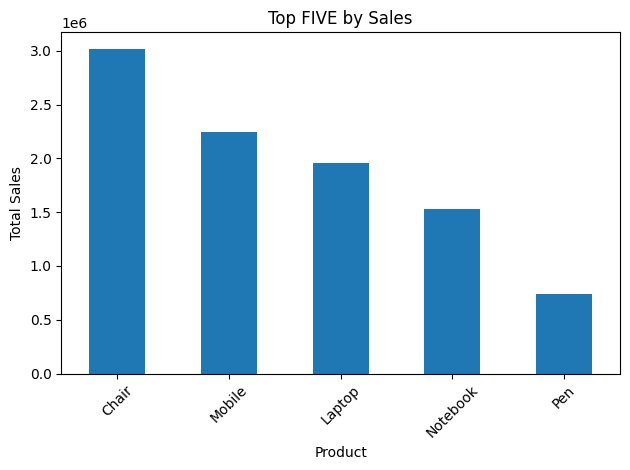

In [23]:
top_5_products.plot(kind="bar")
plt.title("Top FIVE by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
profit_by_category = df.groupby("Category")['Profit'].sum()
print(profit_by_category)

Category
Furniture          111850.000000
Office Supplies    146733.333333
Technology         259833.333333
Name: Profit, dtype: float64


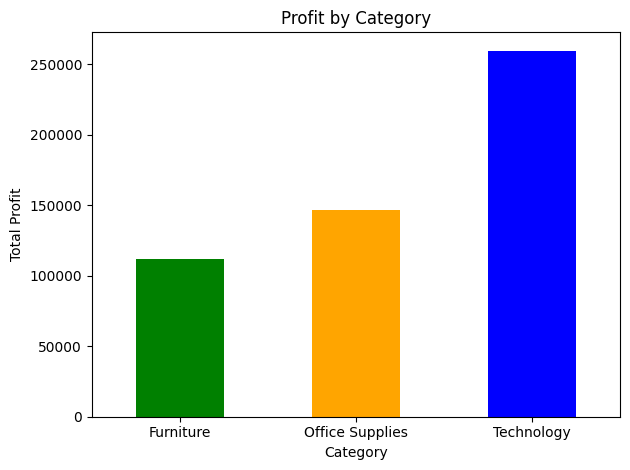

In [25]:
profit_by_category.plot(kind="bar",color=["green","orange","blue"])
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
total_profit = df["Profit"].sum()

profit_percentage = (df.groupby("Category")["Profit"].sum()/total_profit)*100

print(profit_percentage.round(2))

Category
Furniture          21.58
Office Supplies    28.30
Technology         50.12
Name: Profit, dtype: float64


In [27]:
customer_sales=(
    df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False)
)
print(customer_sales)

Customer_Name
Priya Patil          1.583900e+06
Rohan Patil          9.350000e+05
Vrun Dhawan          7.290000e+05
Riya Wagh            5.880000e+05
Rohit Rathor         5.857000e+05
Disha Gore           5.650000e+05
Pradip Bhakad        5.634000e+05
Shruti Ghavhne       5.090000e+05
Rita Patan           4.640000e+05
Amit Joshi           3.916000e+05
Krushna Ukirde       3.760000e+05
Samarth Soni         3.706000e+05
Rohna Vitnor         3.006000e+05
Kiran Bhakre         2.010000e+05
Kartik Patare        2.005600e+05
Sneha More           1.624540e+05
Akash More           1.113000e+05
Divya Khaire         1.003000e+05
Reem Shaikh          1.000000e+05
Pooja Kale           9.771280e+04
Rutuja Kapse         9.083333e+04
Pankaj Wagh          9.000000e+04
Jannat Zubare        9.000000e+04
Rahul Sharma         8.900000e+04
Tanuja Ukirde        8.570000e+04
Rishabh Charan       8.000000e+04
Rushi Sase           7.600000e+04
Rupali Vitnor        7.578800e+04
Sriti Mishra         7.000000e+04


In [28]:
top_5_customers=customer_sales.head(5)
print(top_5_customers)

Customer_Name
Priya Patil     1583900.0
Rohan Patil      935000.0
Vrun Dhawan      729000.0
Riya Wagh        588000.0
Rohit Rathor     585700.0
Name: Sales, dtype: float64


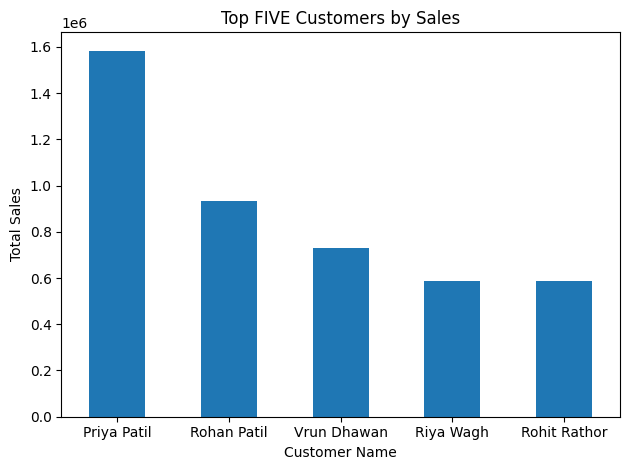

In [29]:
top_5_customers.plot(kind="bar")
plt.title("Top FIVE Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
def update_dashboard(category, region):

    # Filter data
    filtered_df = df.copy()

    if category != "All":
        filtered_df = filtered_df[
            filtered_df["Category"] == category
        ]

    if region != "All":
        filtered_df = filtered_df[
            filtered_df["Region"] == region
        ]

    # KPI calculations
    total_sales = filtered_df["Sales"].sum()
    total_profit = filtered_df["Profit"].sum()
    total_orders = filtered_df["Order_ID"].nunique()

    if total_orders > 0:
        avg_order = total_sales / total_orders
    else:
        avg_order = 0

    # Display KPI
    print("=" * 60)
    print("             SALES ANALYSIS DASHBOARD")
    print("=" * 60)

    print("Category :", category)
    print("Region   :", region)
    print()

    print("💰 Total Sales         : ₹", f"{total_sales:,.0f}")
    print("📈 Total Profit        : ₹", f"{total_profit:,.0f}")
    print("📦 Total Orders        :", total_orders)
    print("🛒 Average Order Value : ₹", f"{avg_order:,.0f}")

    print("=" * 60)

    # Sales by Category
    category_sales = filtered_df.groupby(
        "Category"
    )["Sales"].sum()

    plt.figure(figsize=(8, 5))
    category_sales.plot(kind="bar")
    plt.title("Sales by Category")
    plt.xlabel("Category")
    plt.ylabel("Sales (₹)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Sales by Region
    region_sales = filtered_df.groupby(
        "Region"
    )["Sales"].sum()

    plt.figure(figsize=(7, 7))
    plt.pie(
        region_sales,
        labels=region_sales.index,
        autopct="%1.1f%%"
    )
    plt.title("Sales by Region")
    plt.show()

    # Top Products
    product_sales = filtered_df.groupby(
        "Product"
    )["Sales"].sum().sort_values(ascending=False).head(5)

    plt.figure(figsize=(8, 5))
    product_sales.plot(kind="bar")
    plt.title("Top 5 Products")
    plt.xlabel("Product")
    plt.ylabel("Sales (₹)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Top Customers
    customer_sales = filtered_df.groupby(
        "Customer_Name"
    )["Sales"].sum().sort_values(ascending=False).head(5)

    plt.figure(figsize=(8, 5))
    customer_sales.plot(kind="bar")
    plt.title("Top 5 Customers")
    plt.xlabel("Customer")
    plt.ylabel("Sales (₹)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [33]:
import ipywidgets as widgets
from IPython.display import display

widgets.interact(
    update_dashboard,
    category=category_filter,
    region=region_filter
);

interactive(children=(Dropdown(description='Category:', options=('All', 'Technology', 'Furniture', 'Office Sup…

In [32]:
from os import PRIO_PGRP
print("==== SALES ANALTSIS SUMMARY =====")
print("Total_Sales  :","$",total_sales)
print("Total_Profit :","$",total_profit)
print("Total_Orders :","$",total_orders)
print("Total_Avg_Orders_Values :","$",avg_order_value)



==== SALES ANALTSIS SUMMARY =====
Total_Sales  : $ 10750023.345454546
Total_Profit : $ 518416.6666666666
Total_Orders : $ 100
Total_Avg_Orders_Values : $ 107500.23345454545
